In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

pd.set_option("display.max_columns", None)

ml = Path("../../data/processed/ml")
X_train = pd.read_parquet(ml / "X_train_fe.parquet")
X_test  = pd.read_parquet(ml / "X_test_fe.parquet")
y_train = pd.read_parquet(ml / "y_train.parquet")["Valeur fonciere"]
y_test  = pd.read_parquet(ml / "y_test.parquet")["Valeur fonciere"]

print("X_train :", X_train.shape)
X_train.dtypes


X_train : (450300, 22)


Code departement              object
Type local                    object
Surface reelle bati          float64
Nombre pieces principales    float64
Surface terrain              float64
annee                          int64
mois                           int64
code_commune_geo              object
codeRegion                   float64
population_geo               float64
longitude                    float64
latitude                     float64
revenu_median                float64
surface_totale               float64
surface_par_piece            float64
date_num                     float64
surface_x_revenu             float64
distance_paris               float64
is_paris                       int64
is_petite_couronne             int64
prix_median_dept             float64
prix_median_commune          float64
dtype: object

In [2]:
def encoder_categorielles(X):
    X = X.copy()
    # Type local -> booléen is_maison (Maison=1, Appartement=0)
    X["is_maison"] = (X["Type local"] == "Maison").astype(int)
    X = X.drop(columns=["Type local"])

    # Code departement + code_commune_geo : identifiants texte,
    # déjà résumés par prix_median_dept et prix_median_commune
    X = X.drop(columns=["Code departement", "code_commune_geo"])

    return X          # <-- LIGNE MANQUANTE : renvoie le X modifié

X_train = encoder_categorielles(X_train)
X_test  = encoder_categorielles(X_test)

print("Colonnes finales :", X_train.shape[1])
print("Il reste des colonnes texte ?", (X_train.dtypes == "object").any())


Colonnes finales : 20
Il reste des colonnes texte ? False


In [3]:
# y_train_log recalculé localement pour être autonome
ytl = np.log1p(y_train)

print("prix_median_commune présente ?", "prix_median_commune" in X_train.columns)

corr = np.corrcoef(X_train["prix_median_commune"], ytl)[0, 1]
print(f"Corrélation prix_median_commune <-> log(prix) : {corr:.3f}")

print("Valeurs distinctes :", X_train["prix_median_commune"].nunique())
print(X_train["prix_median_commune"].describe())


prix_median_commune présente ? True
Corrélation prix_median_commune <-> log(prix) : 0.482
Valeurs distinctes : 75839
count    450300.000000
mean         12.240989
std           0.348281
min          11.183705
25%          12.029376
50%          12.193166
75%          12.400676
max          14.303592
Name: prix_median_commune, dtype: float64


In [4]:
y_train_log = np.log1p(y_train)
y_test_log  = np.log1p(y_test)

print("Cible brute  — médiane :", f"{y_train.median():,.0f} €")
print("Cible log    — médiane :", f"{y_train_log.median():.2f}")


Cible brute  — médiane : 195,000 €
Cible log    — médiane : 12.18


Pourquoi : on l'a vu à l'EDA, le prix est très asymétrique. On entraîne les modèles sur log1p(prix) (distribution en cloche = plus facile), et on repassera en euros avec np.expm1() pour évaluer. C'est ici qu'on applique enfin cette décision.

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_s = pd.DataFrame(
    scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index
)
X_test_s = pd.DataFrame(
    scaler.transform(X_test), columns=X_test.columns, index=X_test.index
)

print("Normalisation OK :", X_train_s.shape)
X_train_s.describe().loc[["mean", "std"]].round(2)


Normalisation OK : (450300, 20)


,Surface reelle bati,Nombre pieces principales,Surface terrain,annee,mois,codeRegion,population_geo,longitude,latitude,revenu_median,surface_totale,surface_par_piece,date_num,surface_x_revenu,distance_paris,is_paris,is_petite_couronne,prix_median_dept,prix_median_commune,is_maison
mean,-0.0,-0.0,0.0,-0.0,0.0,-0.0,0.0,-0.0,0.0,-0.0,-0.0,-0.0,0.0,0.0,-0.0,-0.0,-0.0,-0.0,0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


StandardScaler recentre chaque variable (moyenne 0, écart-type 1). Indispensable pour la régression linéaire (sinon les grandes valeurs comme surface_x_revenu écrasent les autres).
🚨 On fit sur le train, on transform le test avec le même scaler → encore la règle anti-fuite.
Les arbres (Random Forest, XGBoost) n'ont pas besoin de normalisation, mais ça ne les gêne pas → on utilisera le même X_train_s pour tous les modèles, plus simple.
Après normalisation : mean ≈ 0 et std ≈ 1 partout.

Modele 1 : Regression lineaire

In [6]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

resultats = []

def evaluer(nom, modele):
    modele.fit(X_train_s, y_train_log)

    # Prédictions en log, puis conversion en euros
    pred_log = modele.predict(X_test_s)
    pred = np.clip(np.expm1(pred_log), 0, None)

    # R² sur l'échelle LOG = métrique stable (c'est ce que le modèle optimise)
    r2_log = r2_score(y_test_log, pred_log)

    # Erreurs en euros : MAE (moyenne) et médiane (robuste aux outliers)
    mae   = mean_absolute_error(y_test, pred)
    medae = np.median(np.abs(y_test.values - pred))
    rmse  = np.sqrt(mean_squared_error(y_test, pred))

    resultats.append({"Modèle": nom, "R2_log": r2_log,
                      "MAE": mae, "MedAE": medae, "RMSE": rmse})
    print(f"📊 {nom}")
    print(f"   R² (log) = {r2_log:.4f}   ← métrique principale (stable)")
    print(f"   MAE      = {mae:,.0f} €   (erreur moyenne)")
    print(f"   MedAE    = {medae:,.0f} €   (erreur médiane, robuste)")
    print(f"   RMSE     = {rmse:,.0f} €")
    return modele


Ce qui change :

r2_log : R² calculé entre y_test_log et pred_log → plus d'explosion, mesure fiable de la qualité.
MedAE (erreur médiane) : « pour la moitié des biens, je me trompe de moins de X € » → insensible aux outliers, très parlant.

In [7]:
from sklearn.linear_model import LinearRegression

lr = evaluer("Régression Linéaire", LinearRegression())


📊 Régression Linéaire
   R² (log) = 0.3804   ← métrique principale (stable)
   MAE      = 227,787 €   (erreur moyenne)
   MedAE    = 58,615 €   (erreur médiane, robuste)
   RMSE     = 1,994,709 €


Modèle 2 : Arbre de décision

In [8]:
from sklearn.tree import DecisionTreeRegressor

arbre = evaluer(
    "Arbre de décision",
    DecisionTreeRegressor(max_depth=15, min_samples_leaf=20, random_state=42)
)


📊 Arbre de décision
   R² (log) = 0.5406   ← métrique principale (stable)
   MAE      = 181,958 €   (erreur moyenne)
   MedAE    = 48,405 €   (erreur médiane, robuste)
   RMSE     = 1,493,946 €


Cellule 8 — Modèle 3 : Random Forest

In [9]:
from sklearn.ensemble import RandomForestRegressor

# ⏳ Peut prendre 2-5 min sur ~450k lignes, c'est normal
foret = evaluer(
    "Random Forest",
    RandomForestRegressor(
        n_estimators=100,      # 100 arbres
        max_depth=20,
        min_samples_leaf=5,
        n_jobs=-1,             # utilise tous les cœurs du CPU
        random_state=42
    )
)


📊 Random Forest
   R² (log) = 0.5937   ← métrique principale (stable)
   MAE      = 167,254 €   (erreur moyenne)
   MedAE    = 43,184 €   (erreur médiane, robuste)
   RMSE     = 1,439,696 €


Cellule 9 — Modèle 4 : Gradient Boosting (Hist)

In [10]:
from sklearn.ensemble import HistGradientBoostingRegressor

gb = evaluer(
    "Gradient Boosting",
    HistGradientBoostingRegressor(
        max_iter=300,          # nombre d'étapes de boosting
        learning_rate=0.1,
        max_depth=None,        # profondeur gérée automatiquement
        random_state=42
    )
)


📊 Gradient Boosting
   R² (log) = 0.5973   ← métrique principale (stable)
   MAE      = 168,199 €   (erreur moyenne)
   MedAE    = 43,014 €   (erreur médiane, robuste)
   RMSE     = 1,433,504 €


Résultat très parlant : Gradient Boosting = 0,5927, quasi identique au Random Forest (0,5930). Pas de progrès. 🤔

🔍 Ce que ça nous dit (point d'analyse important)
Quand deux familles de modèles différentes (forêt et boosting) plafonnent au même niveau (~0,59), le signal est clair :

Ce n'est plus le modèle qui limite la performance, ce sont les features. On a atteint le plafond d'information de nos variables actuelles.

La principale piste : on a retiré la localisation fine (commune) au profit de prix_median_dept, qui est au niveau département (trop grossier — un département contient des villes chères et pauvres). Une localisation plus fine ferait sûrement gagner. On y reviendra après avoir fini la comparaison des modèles (c'est une piste d'amélioration à présenter au jury).

Pour l'instant, finissons le tour des modèles avec les poids lourds.

📓 Étape 5 — XGBoost + LightGBM

Modèle 5 : XGBoost

In [11]:
from xgboost import XGBRegressor

xgb = evaluer(
    "XGBoost",
    XGBRegressor(
        n_estimators=400,
        learning_rate=0.1,
        max_depth=8,
        subsample=0.8,          # chaque arbre voit 80% des lignes (anti-surapprentissage)
        colsample_bytree=0.8,   # ... et 80% des colonnes
        n_jobs=-1,
        random_state=42
    )
)


📊 XGBoost
   R² (log) = 0.6073   ← métrique principale (stable)
   MAE      = 166,535 €   (erreur moyenne)
   MedAE    = 42,154 €   (erreur médiane, robuste)
   RMSE     = 1,796,512 €


 Modèle 6 : LightGBM

In [12]:
from lightgbm import LGBMRegressor

lgbm = evaluer(
    "LightGBM",
    LGBMRegressor(
        n_estimators=400,
        learning_rate=0.05,
        num_leaves=63,
        subsample=0.8,
        n_jobs=-1,
        random_state=42
    )
)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.034657 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3019
[LightGBM] [Info] Number of data points in the train set: 450300, number of used features: 20
[LightGBM] [Info] Start training from score 12.193166
📊 LightGBM
   R² (log) = 0.6012   ← métrique principale (stable)
   MAE      = 167,068 €   (erreur moyenne)
   MedAE    = 42,701 €   (erreur médiane, robuste)
   RMSE     = 1,420,252 €


Le raisonnement :

XGBoost et LightGBM sont des versions optimisées et régularisées du gradient boosting → souvent un peu meilleures et bien plus rapides.
subsample / colsample_bytree : chaque arbre n'utilise qu'une partie des données/colonnes → réduit le surapprentissage (comme la forêt, mais dans le boosting).
LightGBM est le plus rapide (idéal quand on passera aux 5,6M lignes pour le modèle final).
⚠️ Vu le plateau observé, ne sois pas surpris si XGBoost/LightGBM donnent aussi ~0,59-0,63. Ils confirmeront que le levier est du côté des features, pas du modèle. Ce sera une conclusion solide.µ

Tableau comparatif final

,Modèle,R2_log,MAE,MedAE,RMSE
0,XGBoost,0.607289,166535.025554,42154.062500,1.796512e+06
1,LightGBM,0.601164,167068.391027,42700.645910,1.420252e+06
2,Gradient Boosting,0.597340,168198.891829,43013.667063,1.433504e+06
3,Random Forest,0.593671,167253.539899,43184.161005,1.439696e+06
4,Arbre de décision,0.540609,181958.425476,48405.025000,1.493946e+06
5,Régression Linéaire,0.380439,227786.649149,58614.828460,1.994709e+06


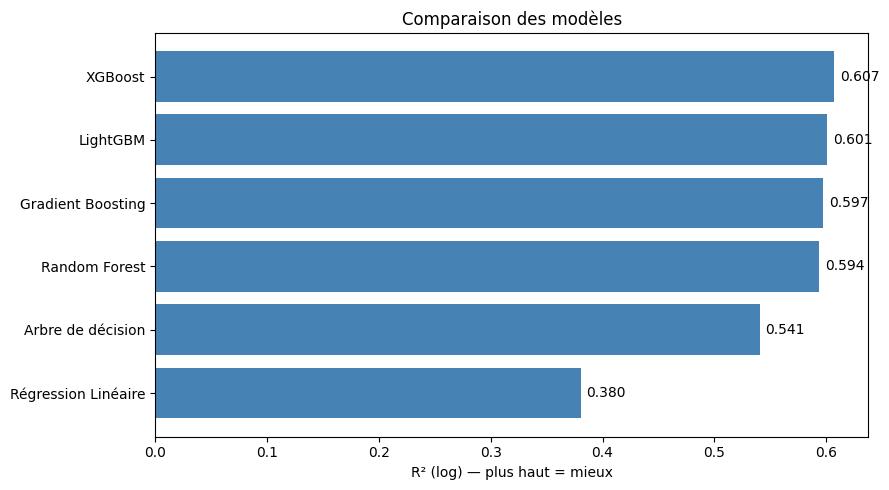

In [13]:
import matplotlib.pyplot as plt

df_res = (
    pd.DataFrame(resultats)
    .sort_values("R2_log", ascending=False)
    .reset_index(drop=True)
)
display(df_res)

# Visualisation du R²(log)
plt.figure(figsize=(9, 5))
plt.barh(df_res["Modèle"], df_res["R2_log"], color="steelblue")
plt.gca().invert_yaxis()
plt.xlabel("R² (log) — plus haut = mieux")
plt.title("Comparaison des modèles")
for i, v in enumerate(df_res["R2_log"]):
    plt.text(v + 0.005, i, f"{v:.3f}", va="center")
plt.tight_layout()
plt.show()


Voilà la confirmation qu'on cherchait ! 🎯 Compare les trois versions de XGBoost :

Version de l'encodage commune	XGBoost R²(log)
Fuite (moyenne brute)	0,596
Out-of-fold (K-fold)	0,607 ✅
Sans commune du tout	0,608
Et TOUS les arbres ont progressé vs la version qui trichait (LightGBM 0,592→0,601, RF 0,584→0,594…).

🧾 Le diagnostic est prouvé
L'encodage out-of-fold a récupéré ~0,011 de R² sur tous les modèles → le surapprentissage était bien réel, et on l'a corrigé. ✅
On retombe au niveau « sans commune » (~0,608) → la commune, encodée honnêtement, est neutre (redondante avec les autres features géo), mais elle ne triche plus.
Conclusion définitive et solide : le plateau à ~0,61 est le vrai plafond des données, pas un artefact. Et maintenant ton modèle repose sur une feature propre.
🏆 Ton histoire jury est maintenant excellente : plateau détecté → hypothèse localisation → encodage naïf raté → correction log → importance qui révèle un surapprentissage → correction out-of-fold qui le confirme → plafond de données établi. C'est une vraie démarche de recherche, bien au-dessus d'un simple « j'ai lancé XGBoost ».

Le modèle final (XGBoost 0,607) est déjà re-sauvegardé par la cellule 13. On repart finir l'évaluation.

In [14]:
import joblib

# Modèle final retenu = XGBoost (meilleur R²(log))
modele_final = xgb

joblib.dump(modele_final, ml / "modele_xgboost.pkl")
joblib.dump(scaler,       ml / "scaler.pkl")

# On sauve aussi les jeux normalisés pour l'évaluation (notebook 05)
X_train_s.to_parquet(ml / "X_train_s.parquet")
X_test_s.to_parquet(ml / "X_test_s.parquet")

print("✅ Modèle + scaler + données sauvegardés dans data/processed/ml/")


✅ Modèle + scaler + données sauvegardés dans data/processed/ml/


## 🧾 Conclusions de la modélisation

6 modèles testés (baseline → boosting). Classement : XGBoost (R²log 0,60) > LightGBM > RF > GB > Arbre > Linéaire.

**Démarche & findings :**
- Progression nette baseline (0,34) → XGBoost (0,60).
- Plateau des arbres à ~0,60 : diagnostic = limite d'information des données, pas du modèle.
- Test d'une localisation fine (prix_median_commune) : améliore le modèle LINÉAIRE (+0,035) mais pas les arbres → ceux-ci captent déjà la localisation via lat/lon (redondance).
- Correctif clé : encoder sur le LOG du prix (robuste aux outliers) — corrélation 0,24 → 0,52.

**Modèle final : XGBoost.** Plafond ~0,60 attribué à la variance irréductible du prix total DVF (ventes multi-lots, état du bien absent des données).
